<a href="https://colab.research.google.com/github/vcbonani/Python/blob/main/Desafios_Estat%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sobre o notebook**

Aproveite esse espaço para as atividades do curso de **Estatística com Python: resumindo e analisando dados** da Alura. Aqui você pode escrever e testar os códigos dos diversos exercícios do **Mão na Massa** envolvendo os aprendizados de cada aula.

Utilizando os conhecimentos adquiridos ao longo do curso, você precisará realizar uma **análise descritiva** básica de um conjunto de dados retirados da **Pesquisa Nacional por Amostra de Domicílios - 2015** do IBGE.

Nele, você irá avaliar os tipos dos dados e suas distribuições, calcular as medidas de tendência central, medidas separatrizes e de dispersão dos dados e construirá visuais como histogramas, boxplot, entre outras para responder às perguntas.

Este notebook foi construído com espaços para adicionar as células dos desafios propostos no curso, com eles você tem espaço para construir e executar suas soluções.





## **Dataset do Projeto**

O conjunto de dados que será explorado aqui é uma adaptação dos dados da **Pesquisa Nacional por Amostra de Domicílios - PNAD**. Ela investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas.

O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### **Fonte dos Dados**

https://www.ibge.gov.br/estatisticas/sociais/populacao/9127-pesquisa-nacional-por-amostra-de-domicilios.html?edicao=9128

### **Variáveis do dataset**

> ### UF
> ***

Unidade federativa da pessoa responsável

> ### Sexo
> ***

Sexo biológico da pessoa responsável

<br>

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Idade
> ***

Idade da pessoa responsável na data de referência em anos.

> ### Cor
> ***

Cor ou raça da pessoa responsável com base na autodeclaração

<br>

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|

> ### Anos de Estudo
> ***

Anos de estudo da pessoa responsável

<br>

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados|

> ### Renda
> ***

Rendimento mensal do trabalho principal da pessoa responsável para 10 anos ou mais de idade.

> ### Altura (elaboração própria - dado sintético)
> ***

Altura da pessoa responsável em metros.

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a **Renda** era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a **Renda** era missing;
> 3. Foram considerados somente os registros das **Pessoas de Referência** de cada domicílio (responsável pelo domicílio).

## **Aula 01 - Entendendo os dados**

### **Mão na Massa - Explorando novos dados**




Você está treinando para ser uma pessoa cientista de dados e recebeu a demanda de investigar os dados da PNAD de 2015. A fim de testar as suas habilidades de análise de dados e os conceitos da estatística descritiva, responda às perguntas ao longo do notebook compartilhado.

#### **Importando os pacotes e configurando o ambiente**

In [1]:
# Importando os pacotes do projeto
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **Importe o dataset e armazene o conteúdo em um DataFrame**

**Dica:** Passe a url para a função que lê um arquivo do tipo `.csv`

In [2]:
url = "https://raw.githubusercontent.com/alura-cursos/Estatisticas-Python-frequencias-medidas/refs/heads/main/dados/dados_desafio.csv"
dados = pd.read_csv(url)

#### **Visualize o conteúdo do DataFrame e leia as infos sobre os dados (linhas, colunas, tipos)**

**Dica:** Para observar as infos dos dados, utilize a função `info`

In [3]:
#visualizando dataframe
dados

,UF,Sexo,Idade,Cor,Anos.de.Estudo,Renda,Altura
0,Rondônia,0,23,8,12,800,1.60
1,Rondônia,1,23,2,12,1150,1.74
2,Rondônia,1,35,8,15,880,1.76
3,Rondônia,0,46,2,6,3500,1.78
4,Rondônia,1,47,8,9,150,1.69
...,...,...,...,...,...,...,...
76835,Distrito Federal,1,46,2,11,812,1.69
76836,Distrito Federal,0,30,4,7,1500,1.79
76837,Distrito Federal,0,32,8,12,1300,1.83
76838,Distrito Federal,0,57,8,4,1500,1.73


In [4]:
#verificando linhas, colunas, tipos de dados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76840 entries, 0 to 76839
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UF              76840 non-null  object 
 1   Sexo            76840 non-null  int64  
 2   Idade           76840 non-null  int64  
 3   Cor             76840 non-null  int64  
 4   Anos.de.Estudo  76840 non-null  int64  
 5   Renda           76840 non-null  int64  
 6   Altura          76840 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 4.1+ MB


In [5]:
#obtendo dados estatísticos da base
dados.describe()

,Sexo,Idade,Cor,Anos.de.Estudo,Renda,Altura
count,76840.000000,76840.000000,76840.000000,76840.000000,76840.000000,76840.000000
mean,0.307002,44.071421,5.032613,9.469664,2000.383199,1.699508
std,0.461253,12.480583,2.857118,4.539929,3323.387730,0.079788
min,0.000000,13.000000,0.000000,1.000000,0.000000,1.340000
25%,0.000000,34.000000,2.000000,6.000000,788.000000,1.650000
50%,0.000000,43.000000,4.000000,11.000000,1200.000000,1.700000
75%,1.000000,53.000000,8.000000,12.000000,2000.000000,1.750000
max,1.000000,99.000000,8.000000,17.000000,200000.000000,2.030000


#### **Explore brevemente a variável `UF` e investigue quantos dados possuímos para cada estado**

**Dica:** Para explorar, utilize as funções `unique`, `value_counts`, `reset_index` e `barplot`



In [6]:
#verificando os valores únicos de UF
dados['UF'].unique()

array(['Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá',
       'Tocantins', 'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte',
       'Paraíba', 'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia',
       'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo',
       'Paraná', 'Santa Catarina', 'Rio Grande do Sul',
       'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal'],
      dtype=object)

In [7]:
#gerando um df exclusivo com a contagem de amostras por estado
dados_uf = dados['UF'].value_counts().reset_index()
dados_uf

,UF,count
0,São Paulo,8544
1,Minas Gerais,7686
2,Rio Grande do Sul,6322
3,Bahia,5717
4,Rio de Janeiro,5556
5,Pará,4449
6,Paraná,4356
7,Pernambuco,3820
8,Goiás,3478
9,Ceará,3359


In [8]:
#obtendo dados estatísticos das amostras por UF
dados_uf.describe()

,count
count,27.000000
mean,2845.925926
std,2242.195729
min,512.000000
25%,1280.500000
50%,1800.000000
75%,4088.000000
max,8544.000000


<BarContainer object of 27 artists>

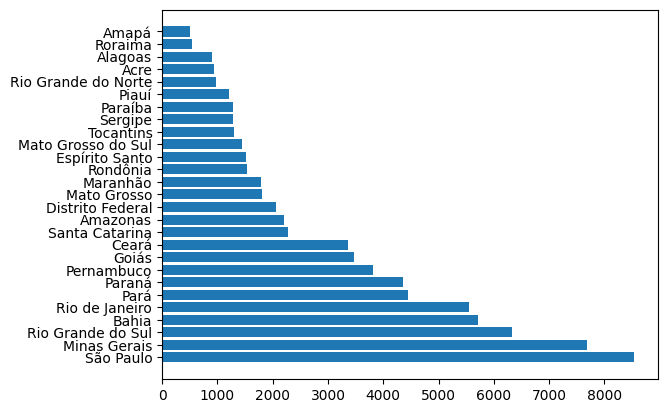

In [9]:
#gerando gráfico de barras horizontal com a contagem de amostras por estado
plt.barh(dados_uf['UF'], dados_uf['count'])

#### **Transforme as variáveis `Sexo`, `Cor` e `Anos.de.Estudo` em Categorical e observe o resultado**

**Dica 1:** Para te auxiliar neste processo, a célula abaixo traz os vetores com os valores de cada coluna na ordem desejada.

**Dica 2:** Utilize a tabela no início do documento para fazer a relação dos valores atuais para os desejados.

In [10]:
# Definindo as variáveis
sexo = {0: 'Masculino', 1: 'Feminino'}

cor = {0:'Indígena', 2:'Branca', 4:'Preta', 6:'Amarela', 8:'Parda'}

anos_de_estudo = {1:'Sem instrução e menos de 1 ano', 2:'1 ano', 3:'2 anos', 4:'3 anos', 5:'4 anos', 6:'5 anos',
    7:'6 anos', 8:'7 anos', 9:'8 anos', 10:'9 anos', 11:'10 anos', 12:'11 anos', 13:'12 anos',14:'13 anos',
    15:'14 anos', 16:'15 anos ou mais', 17:'Não determinados'
}

sexo.keys()

dict_keys([0, 1])

In [11]:
#Criando as colunas categóricas de sexo, cor, anos de estudo
dados['sexo_nome'] = pd.Categorical(dados['Sexo'], categories = sexo.keys(), ordered = True)
dados['cor_nome'] = pd.Categorical(dados['Cor'], categories = cor.keys(), ordered = True)
dados['anos_de_estudo_nome'] = pd.Categorical(dados['Anos.de.Estudo'], categories = anos_de_estudo.keys(), ordered = True)

In [12]:
#checando df atualizado
dados

,UF,Sexo,Idade,Cor,Anos.de.Estudo,Renda,Altura,sexo_nome,cor_nome,anos_de_estudo_nome
0,Rondônia,0,23,8,12,800,1.60,0,8,12
1,Rondônia,1,23,2,12,1150,1.74,1,2,12
2,Rondônia,1,35,8,15,880,1.76,1,8,15
3,Rondônia,0,46,2,6,3500,1.78,0,2,6
4,Rondônia,1,47,8,9,150,1.69,1,8,9
...,...,...,...,...,...,...,...,...,...,...
76835,Distrito Federal,1,46,2,11,812,1.69,1,2,11
76836,Distrito Federal,0,30,4,7,1500,1.79,0,4,7
76837,Distrito Federal,0,32,8,12,1300,1.83,0,8,12
76838,Distrito Federal,0,57,8,4,1500,1.73,0,8,4


In [13]:
#mapeando as colunas de nome com seus respectivos dicionários
dados['sexo_nome'] = dados['sexo_nome'].map(sexo)
dados['cor_nome'] = dados['cor_nome'].map(cor)
dados['anos_de_estudo_nome'] = dados['anos_de_estudo_nome'].map(anos_de_estudo)

In [14]:
#checando df atualizado
dados

,UF,Sexo,Idade,Cor,Anos.de.Estudo,Renda,Altura,sexo_nome,cor_nome,anos_de_estudo_nome
0,Rondônia,0,23,8,12,800,1.60,Masculino,Parda,11 anos
1,Rondônia,1,23,2,12,1150,1.74,Feminino,Branca,11 anos
2,Rondônia,1,35,8,15,880,1.76,Feminino,Parda,14 anos
3,Rondônia,0,46,2,6,3500,1.78,Masculino,Branca,5 anos
4,Rondônia,1,47,8,9,150,1.69,Feminino,Parda,8 anos
...,...,...,...,...,...,...,...,...,...,...
76835,Distrito Federal,1,46,2,11,812,1.69,Feminino,Branca,10 anos
76836,Distrito Federal,0,30,4,7,1500,1.79,Masculino,Preta,6 anos
76837,Distrito Federal,0,32,8,12,1300,1.83,Masculino,Parda,11 anos
76838,Distrito Federal,0,57,8,4,1500,1.73,Masculino,Parda,3 anos


In [15]:
#reordenando colunas
dados = dados[['UF', 'Sexo', 'sexo_nome', 'Idade', 'Cor', 'cor_nome', 'Anos.de.Estudo', 'anos_de_estudo_nome',
               'Altura', 'Renda']]

#checando df atualizado
dados

,UF,Sexo,sexo_nome,Idade,Cor,cor_nome,Anos.de.Estudo,anos_de_estudo_nome,Altura,Renda
0,Rondônia,0,Masculino,23,8,Parda,12,11 anos,1.60,800
1,Rondônia,1,Feminino,23,2,Branca,12,11 anos,1.74,1150
2,Rondônia,1,Feminino,35,8,Parda,15,14 anos,1.76,880
3,Rondônia,0,Masculino,46,2,Branca,6,5 anos,1.78,3500
4,Rondônia,1,Feminino,47,8,Parda,9,8 anos,1.69,150
...,...,...,...,...,...,...,...,...,...,...
76835,Distrito Federal,1,Feminino,46,2,Branca,11,10 anos,1.69,812
76836,Distrito Federal,0,Masculino,30,4,Preta,7,6 anos,1.79,1500
76837,Distrito Federal,0,Masculino,32,8,Parda,12,11 anos,1.83,1300
76838,Distrito Federal,0,Masculino,57,8,Parda,4,3 anos,1.73,1500


#### **Apresente em texto a menor e maior `Renda` da base de dados**

**Dica:** A renda é uma medida discreta. Utilizamos f-strings para formatar a string de forma mais legível e eficiente, substituindo diretamente as variáveis dentro da string

In [16]:
#obtendo a maior e menor renda e imprimindo na tela
maior_renda = dados['Renda'].max()
menor_renda = dados['Renda'].min()
print(f'A maior renda registrada na base é {maior_renda:.2f} e a menor renda é {menor_renda:.2f}')

A maior renda registrada na base é 200000.00 e a menor renda é 0.00


## **Aula 02 - Identificando o perfil do público**

### **Mão na Massa - Analisando o perfil das pessoas responsáveis**

Vamos prosseguir no treinamento, agora identificando o perfil das pessoas responsáveis pelo domicílio de acordo com os dados da PNAD de 2015. Responda às perguntas abaixo e reflita sobre os achados.

#### **Construa uma tabela de frequências das pessoas responsáveis pelo domicílio por `Cat.Sexo`. Adicione também uma coluna com esse valor em porcentagem.**

In [17]:
frequencia_sexo = (dados.groupby('sexo_nome').size().reset_index(name = 'freq_absoluta'))
frequencia_sexo['freq_relativa'] = round(frequencia_sexo['freq_absoluta'] / frequencia_sexo['freq_absoluta'].sum(), 2) * 100

/tmp/ipykernel_11907/825862902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequencia_sexo = (dados.groupby('sexo_nome').size().reset_index(name = 'freq_absoluta'))


In [18]:
frequencia_sexo.head()

#Há mais responsáveis pelos domicílios do sexo masculino do que do sexo feminino. A diferença é de mais de 30%

,sexo_nome,freq_absoluta,freq_relativa
0,Masculino,53250,69.0
1,Feminino,23590,31.0


#### **Construa uma tabela de frequências absolutas e outra de relativas cruzando as variáveis `Cat.Sexo` e `Cat.Cor` das pessoas responsáveis pelo domicílio.**

In [19]:
freq_sexo_cor_absoluta = pd.crosstab(dados['sexo_nome'], dados['cor_nome'])
freq_sexo_cor_absoluta

cor_nome,Indígena,Branca,Preta,Amarela,Parda
sexo_nome,,,,,
Masculino,256,22194,5502,235,25063
Feminino,101,9621,2889,117,10862


In [20]:
freq_sexo_cor_relativa = round(pd.crosstab(dados['sexo_nome'], dados['cor_nome'], normalize = 'all') * 100, 2)
freq_sexo_cor_relativa

cor_nome,Indígena,Branca,Preta,Amarela,Parda
sexo_nome,,,,,
Masculino,0.33,28.88,7.16,0.31,32.62
Feminino,0.13,12.52,3.76,0.15,14.14


> #### Conclusões

No total geral, predominam homens da cor parda como responsáveis por seus domicílios. Com 4% a menos, vemos homens da cor branca. Para as mulheres, há apenas uma diferença de 2% entre mulheres da cor prada e mulheres da cor branca. Para ambos os sexos, predominam pessoas pardas e brancas como responsáveis por seus domicílios. Chama a atenção que menos de 1% da população respondente em ambos os sexos seja de pessoas indígenas e amarelas.

#### **Construa uma tabela cruzada para calcular a `Renda` média das pessoas responsáveis pelo domicílio em relação ao `Cat.Sexo` e `Cat.Cor`.**

In [21]:
tab_renda_sexo_cor = round(pd.crosstab(dados['sexo_nome'], dados['cor_nome'], values = dados['Renda'], aggfunc = 'mean'), 2)
tab_renda_sexo_cor

cor_nome,Indígena,Branca,Preta,Amarela,Parda
sexo_nome,,,,,
Masculino,1081.71,2925.74,1603.86,4758.25,1659.58
Feminino,2464.39,2109.87,1134.60,3027.34,1176.76


> #### Conclusões

No geral, pessoas da cor amarela possuem uma renda média maior do que das demais cores. No sexo masculino, a cor branca possui a segunda renda média, enquanto as cores parda e preta apresentam uma renda média muito próxima. O homem indígena é o que possui a menor renda média. No sexo feminino, o mesmo padrão do sexo masculino se repete para as cores amarela, branca, preta e parda, porém a mulher indígena possui uma renda média mensal maior que das mulheres da cor parda e preta, sendo esta última a que tem menor renda média mensal entre as mulheres.

## **Aula 03 - Analisando a tendência dos dados**

### **Mão na Massa - Analisando a renda das pessoas responsáveis**

Nesta etapa do treinamento, vamos analisar mais dados das pessoas responsáveis pelo domicílio de acordo com os dados da PNAD de 2015, focando na renda e na variável que criamos com as suas alturas. Responda às perguntas abaixo e reflita sobre os achados.

#### **Calcule as medidas de tendência central (média, mediana e moda) para a variável `Renda`**

In [22]:
#a renda média é aproximadamente 2000
print(f'A média das rendas é: {dados['Renda'].mean():.2f}')

A média das rendas é: 2000.38


In [23]:
#a mediana de renda é 1200
print(f'A mediana das rendas é: {dados['Renda'].median()}')

A mediana das rendas é: 1200.0


In [24]:
#a moda da renda é 788 e aparece 6881 vezes na base
print(f'A moda da Renda é: {int(dados['Renda'].mode()[0])} e aparece {int(dados['Renda'][dados['Renda'] == 788].value_counts())} vezes na base de dados')

A moda da Renda é: 788 e aparece 6881 vezes na base de dados


/tmp/ipykernel_11907/1952739664.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f'A moda da Renda é: {int(dados['Renda'].mode()[0])} e aparece {int(dados['Renda'][dados['Renda'] == 788].value_counts())} vezes na base de dados')


In [25]:
print(f'A maior renda é: {dados['Renda'].max()} e a menor renda registrada é: {dados['Renda'].min()}')

A maior renda é: 200000 e a menor renda registrada é: 0


#### **Crie um gráfico de barras do Top 5 estados pela médias de `Renda`**

**Dica:** Para conseguir apresentar apenas os Top 5 estados utilize a função `head()` passando como variável quantos valores deseja apresentar.

In [26]:
dados_renda_estados = dados.groupby('UF')['Renda'].mean().sort_values(ascending = False).reset_index()
dados_renda_estados_top_5 = dados_renda_estados.head(5).copy()
dados_renda_estados_top_5.columns = ['Estado', 'Renda Média']
dados_renda_estados_top_5

,Estado,Renda Média
0,Distrito Federal,4241.954722
1,São Paulo,2638.104986
2,Rio de Janeiro,2496.403168
3,Paraná,2493.870753
4,Santa Catarina,2470.854945


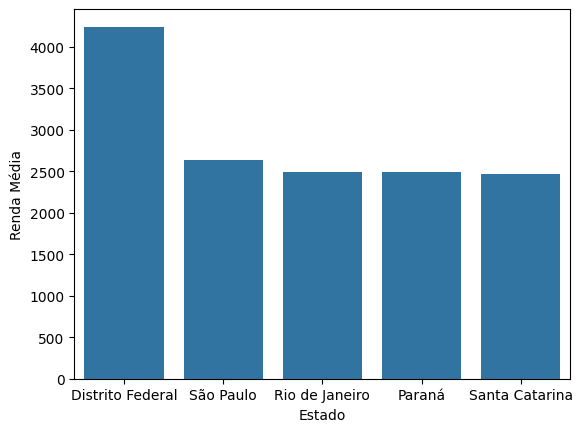

In [27]:
sns.barplot(dados_renda_estados_top_5, x = 'Estado', y = 'Renda Média')
plt.show()

> #### Conclusões

Escreva suas conclusões aqui...

#### **Construa 3 tabelas cruzadas calculando a média, mediana e valores máximos de `Renda` relacionando as pessoas responsáveis por estado da Região Sudeste (`UF`) e por `Cat.Sexo`**

In [28]:
sudeste = ['Espírito Santo', 'Minas Gerais', 'Rio de Janeiro', 'São Paulo']
dados[dados['UF'].isin(sudeste)]['UF']

,UF
31818,Minas Gerais
31819,Minas Gerais
31820,Minas Gerais
31821,Minas Gerais
31822,Minas Gerais
...,...
55110,São Paulo
55111,São Paulo
55112,São Paulo
55113,São Paulo


In [29]:
sudeste_medidas = round(pd.crosstab(dados[dados['UF'].isin(sudeste)]['UF'], dados['sexo_nome'], values = dados['Renda'], aggfunc = ['mean', 'median', 'max']), 2)
sudeste_medidas

mean             median                max         
sexo_nome      Masculino Feminino Masculino Feminino Masculino Feminino
UF                                                                     
Espírito Santo   2129.32  1752.71    1500.0    927.0     40000   100000
Minas Gerais     2283.16  1489.62    1400.0    900.0    100000    30000
Rio de Janeiro   2777.55  1971.53    1510.0   1040.5    200000   120000
São Paulo        2947.74  1950.18    1820.0   1200.0     80000    50000

> #### Conclusões

Escreva suas conclusões aqui...

#### **Construa 2 histogramas com curva de densidade com os valores das colunas `Altura` e `Idade` de todas as pessoas responsáveis e compare as curvas obtidas com as suas  MTCs**

##### **Altura**

In [30]:
medidas_altura = {'media': dados['Altura'].mean(), 'mediana': dados['Altura'].median(), 'moda': dados['Altura'].mode()[0]}
medidas_altura

{'media': np.float64(1.6995084591358667),
 'mediana': 1.7,
 'moda': np.float64(1.7)}

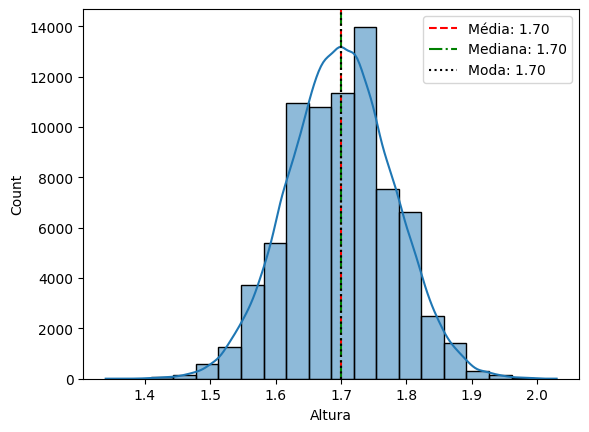

In [31]:
sns.histplot(dados['Altura'], bins = 20, kde = True)
plt.axvline(medidas_altura['media'], color="red", linestyle="--", label=f'Média: {medidas_altura['media']:.2f}')
plt.axvline(medidas_altura['mediana'], color="green", linestyle="-.", label=f'Mediana: {medidas_altura['mediana']:.2f}')
plt.axvline(medidas_altura['moda'], color="black", linestyle=":", label=f'Moda: {medidas_altura['moda']:.2f}')
plt.legend(title='', fontsize=10)

> #### Conclusões

Escreva suas conclusões aqui...

##### **Idade**

In [32]:
medidas_idade = {'media': dados['Idade'].mean(), 'mediana': dados['Idade'].median(), 'moda': dados['Idade'].mode()[0]}
medidas_idade

{'media': np.float64(44.07142113482561), 'mediana': 43.0, 'moda': np.int64(40)}

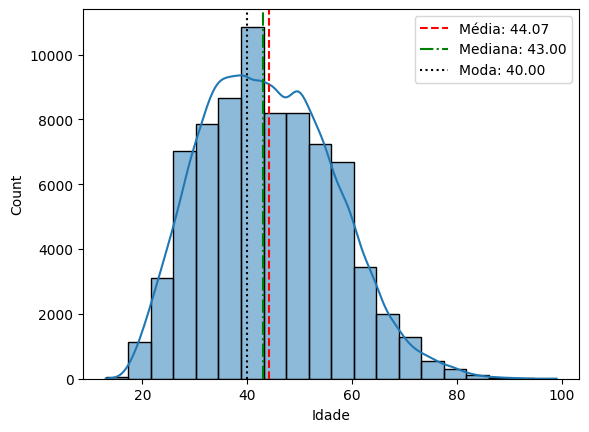

In [33]:
sns.histplot(dados['Idade'], bins = 20, kde = True)
plt.axvline(medidas_idade['media'], color="red", linestyle="--", label=f'Média: {medidas_idade['media']:.2f}')
plt.axvline(medidas_idade['mediana'], color="green", linestyle="-.", label=f'Mediana: {medidas_idade['mediana']:.2f}')
plt.axvline(medidas_idade['moda'], color="black", linestyle=":", label=f'Moda: {medidas_idade['moda']:.2f}')
plt.legend(title='', fontsize=10)

> #### Conclusões

Escreva suas conclusões aqui...

## **Aula 04 - Investigando os dados dos colaboradores**

### **Mão na Massa - Analisando as rendas e suas divisões**

Nesta etapa do treinamento, vamos analisar os dados das pessoas responsáveis pelo domicílio de acordo com os dados da PNAD de 2015, por meio das medidas separatrizes. Responda às perguntas abaixo e reflita sobre os achados.


#### **Calcule o número de classes para `Renda` até R$15.000 utilizando a regra de Sturges**

$$k = 1 + \frac {10}{3}\log_{10}n$$

onde,

$k$ = número de classes

$n$ = número de observações.


In [34]:
#filtrando os dados de renda até 15000 e ordenando pela renda de forma ascendente
dados.query('Renda <= 15000').sort_values('Renda')

#obtendo a quantidade de registros (76219)
n = len(dados.query('Renda <= 15000').sort_values('Renda'))

#importar a biblioteca math para permitir o uso de cálculos matemáticos complexos
import math

#calcular a regra de Sturges para encontrar a quantidade de classes
k = 1 + (10 / 3) * math.log10(n)

#transformando o resultado do k para um inteiro
k = int(k)

print(f'Existem {k} classes para renda até R$15.000,00 utilizando a regra de Sturges')

Existem 17 classes para renda até R$15.000,00 utilizando a regra de Sturges


#### **Crie o histograma da `Renda` das pessoas responsáveis até R$15.000 seguindo o número de classes calculado anteriormente**

> **Observação:** Ao rodar o código para dividir os dados em faixas é possível que você observe o limite inferior da 1ª faixa com um valor negativo. Isto porque a *Regra de Sturges* define o intervalo mínimo da 1ª classe pela seguinte fórmula: $min(Renda) - (max(Renda) - min(Renda)) * 0.001$.



<Axes: xlabel='Renda', ylabel='Count'>

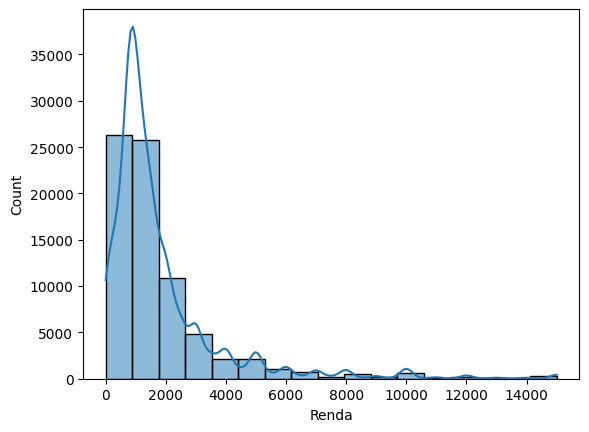

In [35]:
#criando um dataset a parte só com a renda até 15000
dados_ate_quinze = dados.query('Renda <= 15000').sort_values('Renda').copy().reset_index(drop = True)

#incluindo uma coluna no dataset de classe de renda
dados_ate_quinze['Classe_renda'] = pd.cut(dados_ate_quinze['Renda'], bins = k, include_lowest = True)

#criar tabela de frequência absoluta e relativa
tabela_frequencia = dados_ate_quinze.groupby('Classe_renda', observed = False).size().reset_index(name = 'Frequencia')
tabela_frequencia['Porcentagem'] = (tabela_frequencia['Frequencia'] / len(dados_ate_quinze)) * 100

#gerando gráfico de histograma
sns.histplot(data = dados_ate_quinze, x = 'Renda', bins = k, kde = True)

> #### Conclusões

Escreva suas conclusões aqui...

#### **Responda as seguintes questões sobre o nosso dataset completo utilizando os conceitos que estudamos até aqui:**

##### **1. Qual o percentual de pessoas responsáveis que ganhava até um salário mínimo em 2015 (R$ 788,00)?**



In [36]:
print(f'{(dados.query('Renda <= 788')['Renda'].count() / dados['Renda'].count()) * 100:.2f}% dos responsáveis ganham até R$788,00')


28.87% dos responsáveis ganham até R$788,00


##### **2. Qual a renda máxima de 95% das pessoas responsáveis na pesquisa?**


In [37]:
print(f'A renda máxima de 95% das pessoas é de R${dados['Renda'].quantile(0.95):.2f}')

A renda máxima de 95% das pessoas é de R$6000.00


##### **3.   Qual a renda mínima dos 1% mais bem pagos da pesquisa?**

In [38]:
print(f'A renda mínima dos 1% mais bem pagos é de R${dados['Renda'].quantile(0.99):.2f}')

A renda mínima dos 1% mais bem pagos é de R$15000.00


##### **4. Qual a renda máxima de 25%, 50% e 75% das pessoas responsáveis que receberam até R$ 6.000 de rendimento mensal? Construa o boxplot e traga o resumo desses dados.**


In [39]:
#obtendo os percentis de quem ganha até 6000
renda_seis = dados[dados['Renda'] <= 6000].sort_values('Renda').reset_index(drop = True)
renda_seis_25 = renda_seis['Renda'].quantile(0.25)
renda_seis_50 = renda_seis['Renda'].quantile(0.50)
renda_seis_75 = renda_seis['Renda'].quantile(0.75)
print(f'A renda máxima de 25% é: {renda_seis_25}, de 50% é: {renda_seis_50}, de 75% é: {renda_seis_75} que receberam até R$6.000,00 de renda mensal.')

A renda máxima de 25% é: 788.0, de 50% é: 1200.0, de 75% é: 2000.0 que receberam até R$6.000,00 de renda mensal.


<Axes: xlabel='Renda'>

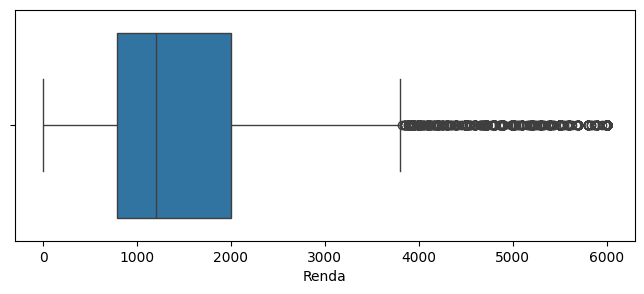

In [40]:
#imprimindo boxplot
plt.figure(figsize = (8, 3))
sns.boxplot(x = renda_seis['Renda'])

> #### Conclusões

Escreva suas conclusões aqui...

#### **Construa o boxplot da `Renda` até o percentil 95% (`renda_6k`) das pessoas responsáveis por `Cat.Sexo` e `Cat.Cor`. Interprete o resultado.**

**Dica:** Para incluir uma 3ª variável na construção de um boxplot, utilize o parâmetro `hue` da seguinte maneira: `(x = Renda, y = Cat.Cor, hue = Cat.Sexo)`.

<Axes: xlabel='Renda', ylabel='cor_nome'>

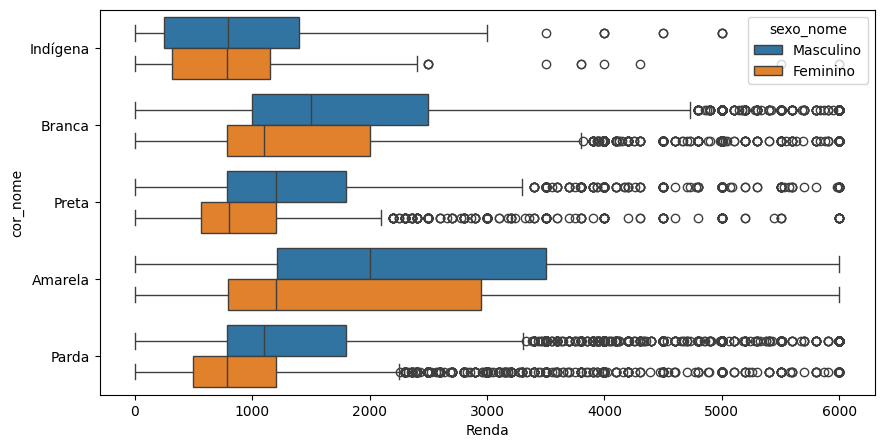

In [41]:
#gerando dataset de quem ganha até 95% da renda
percentil_95 = dados['Renda'].quantile(0.95)
renda_6k = dados[dados['Renda'] <= percentil_95].sort_values('Renda').reset_index(drop = True)

#imprimindo boxplot
plt.figure(figsize = (10, 5))
sns.boxplot(data = renda_6k, x = 'Renda', y = 'cor_nome', hue = 'sexo_nome')

#### **Qual a idade limite para 20% da população? Construa o histograma acumulado com curva de densidade, definindo a idade limite e quantas pessoas se encaixam nessa porcentagem.**

**Dica:** Para ler os últimos valores de um DataFrame utilize a função `tail()`.

Exemplo: `df.tail(3)` lê os ultimos 3 registros do DataFrame `df`.

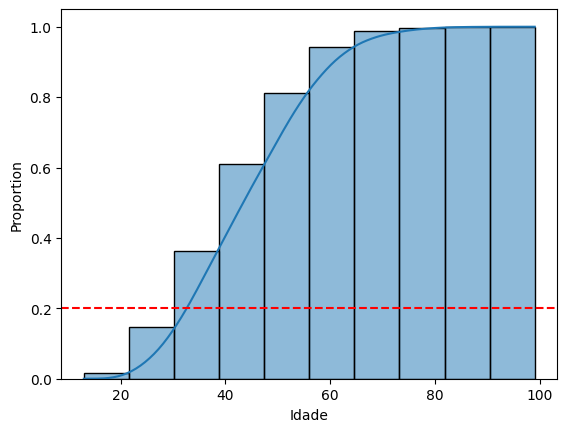

In [42]:
#calculando idade limite para 20% da população - total 76840 - 20% 15368
dados.sort_values('Idade').reset_index(drop = True).iloc[15367]
dados['Idade'].quantile(0.2)

sns.histplot(data = dados, x = 'Idade', bins = 10, cumulative = True, stat = 'proportion', kde = True)
plt.axhline(0.20, color = 'red', linestyle = 'dashed')

> #### Conclusões

Escreva suas conclusões aqui...

## **Aula 05 - Analisando a variação dos dados**

### **Mão na Massa - Analisando a variação da Renda das pessoas responsáveis**

Nesta última etapa do treinamento, vamos analisar os dados de renda das pessoas responsáveis pelo domicílio de acordo com os dados da PNAD de 2015, calculando a variação desta para determinadas características da amostra. Responda às perguntas abaixo e reflita sobre os achados.


#### **Responda as seguintes questões sobre o nosso dataset utilizando os conceitos que estudamos até aqui:**

##### **1.   Qual o desvio médio absoluto, a variância e desvio padrão da renda das pessoas responsáveis na pesquisa?**





In [46]:
estatisticas_dados = dados['Renda'].agg(
    mad = lambda elemento: (abs(elemento - elemento.mean())).mean(),
    variancia = 'var',
    desvio_padrao = 'std'
)

round(estatisticas_dados, 2)

,Renda
mad,1526.50
variancia,11044906.01
desvio_padrao,3323.39


##### **2. Construa uma tabela com a média, mediana e desvio padrão para a renda das pessoas em relação aos Anos de Estudo. O que podemos interpretar com esses dados?**

In [51]:
estatisticas_anos_de_estudo = dados.groupby('anos_de_estudo_nome')['Renda'].agg(
    media = 'mean',
    mediana = 'median',
    desvio_padrao = 'std'
)

estatisticas_anos_de_estudo

/tmp/ipykernel_11907/3738589667.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estatisticas_anos_de_estudo = dados.groupby('anos_de_estudo_nome')['Renda'].agg(


,media,mediana,desvio_padrao
anos_de_estudo_nome,,,
Sem instrução e menos de 1 ano,732.994187,600.0,955.274843
1 ano,806.524496,700.0,1203.866292
2 anos,842.560209,788.0,1298.873800
3 anos,980.044275,788.0,1907.138437
4 anos,1150.439293,900.0,1293.144934
5 anos,1183.575683,940.0,1328.709017
6 anos,1284.082618,1000.0,1326.140204
7 anos,1289.166233,1000.0,1279.412081
8 anos,1437.744862,1100.0,1404.280340


> #### Conclusões

Escreva suas conclusões aqui...

##### **3.   Construa uma tabela com a média, mediana e desvio padrão para a renda das pessoas do sexo biológico masculino e feminino até R$ 15.000. O que podemos interpretar com esses dados?**

In [59]:
sexo_15000 = dados[dados['Renda'] <= 15000].groupby('sexo_nome')['Renda'].agg(
    media = 'mean',
    mediana = 'median',
    desvio_padrao = 'std'
)

sexo_15000

/tmp/ipykernel_11907/2784289004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sexo_15000 = dados[dados['Renda'] <= 15000].groupby('sexo_nome')['Renda'].agg(


,media,mediana,desvio_padrao
sexo_nome,,,
Masculino,1964.351997,1300.0,2101.163468
Feminino,1460.143630,900.0,1763.686374


> #### Conclusões

Escreva suas conclusões aqui...

#### **Construa um boxplot da `Renda` dos estados da Região Centro-Oeste até R$ 10.000 segundo o `Cat.Sexo`. Para interpretar o resultado construa 3 tabelas com cada uma das estatísticas descritivas (média, mediana e desvio padrão).**

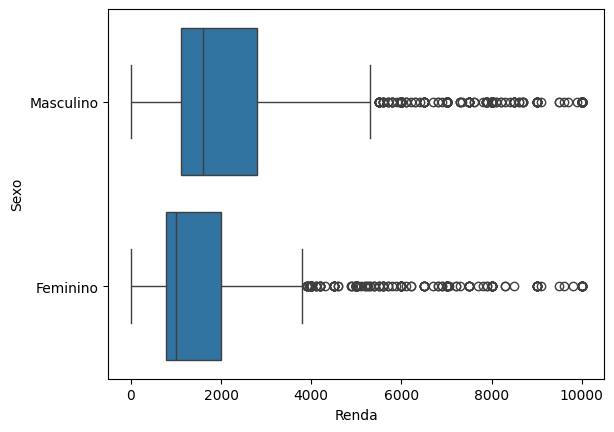

In [87]:
centro_oeste = ['Goiás', 'Mato Grosso', 'Mato Grosso do Sul', 'Distrito Federal']
renda_centro_oeste = dados[(dados['Renda'] <= 10000) & (dados['UF'].isin(centro_oeste))]

sns.boxplot(data = renda_centro_oeste, x = 'Renda', y = 'sexo_nome')
plt.ylabel('Sexo');

In [90]:
media_renda = round(pd.crosstab(renda_centro_oeste['UF'], renda_centro_oeste['sexo_nome'], values = renda_centro_oeste['Renda'], aggfunc = ['mean', 'median', 'std']))
media_renda

mean             median                std         
sexo_nome          Masculino Feminino Masculino Feminino Masculino Feminino
UF                                                                         
Distrito Federal      3138.0   2552.0    2000.0   1400.0    2513.0   2451.0
Goiás                 2030.0   1285.0    1500.0    900.0    1587.0   1110.0
Mato Grosso           2092.0   1549.0    1560.0   1000.0    1708.0   1509.0
Mato Grosso do Sul    2182.0   1397.0    1576.0    986.0    1773.0   1401.0

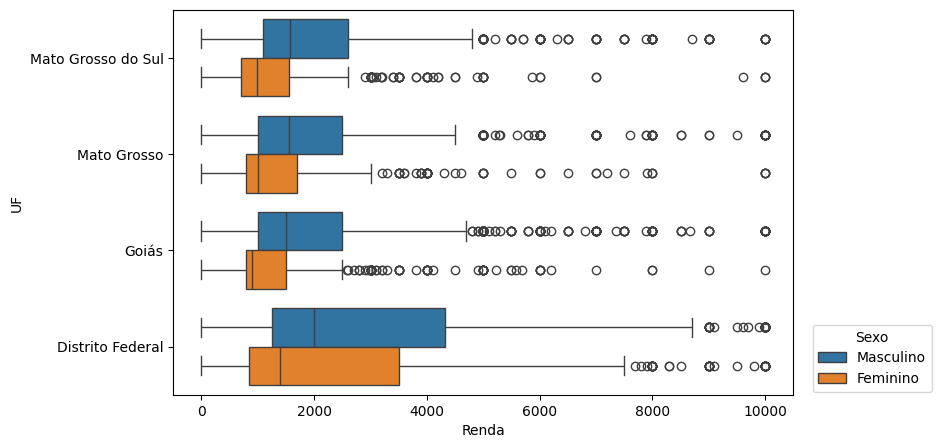

In [111]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = renda_centro_oeste, x = 'Renda', y = 'UF', hue = 'sexo_nome')
plt.legend(title="Sexo", bbox_to_anchor=(1.02, 0.2))


> #### Conclusões

Escreva suas conclusões aqui...